In [1]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('/content/mushroom.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   Unnamed: 0 cap_shape cap_surface cap_color bruises   odor gill_attachment  \
0        1167    sunken       scaly     white      no  anise      descending   
1        1037    sunken     fibrous       red      no  anise         notched   
2         309      flat     grooves    purple     yes   foul      descending   
3         282      bell       scaly      pink     yes  fishy         notched   
4         820      flat      smooth    yellow     yes  musty            free   

  gill_spacing gill_size gill_color  ...  veil_type veil_color ring_number  \
0      distant     broad       pink  ...    partial      brown         two   
1      crowded    narrow  chocolate  ...  universal      brown         two   
2      crowded     broad     purple  ...  universal     yellow         two   
3        close     broad     orange  ...    partial     yellow         two   
4      crowded    narrow     orange  ...  universal      white        none   

   ring_type spore_

## Analyze Feature Distributions

### Subtask:
Utilize histograms or density plots to understand the distribution of numerical features and value counts for categorical features within the dataset.


**Reasoning**:
To understand the distribution of numerical features, I will first identify numerical columns in the DataFrame and then generate histograms for each of them. I will use `matplotlib.pyplot` for plotting.



Numerical columns identified: ['stalk_height', 'cap_diameter']


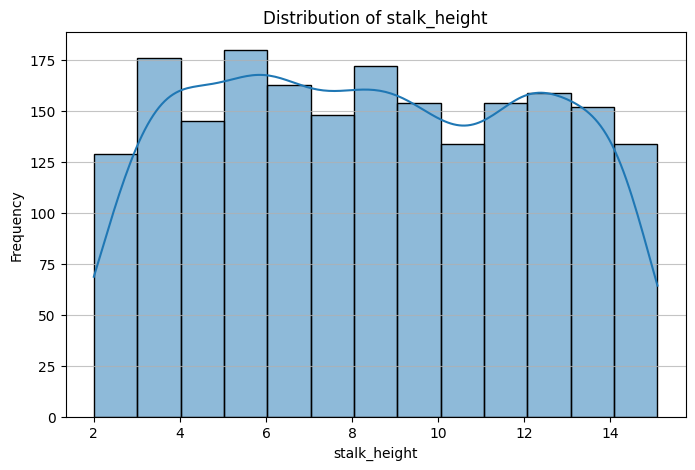

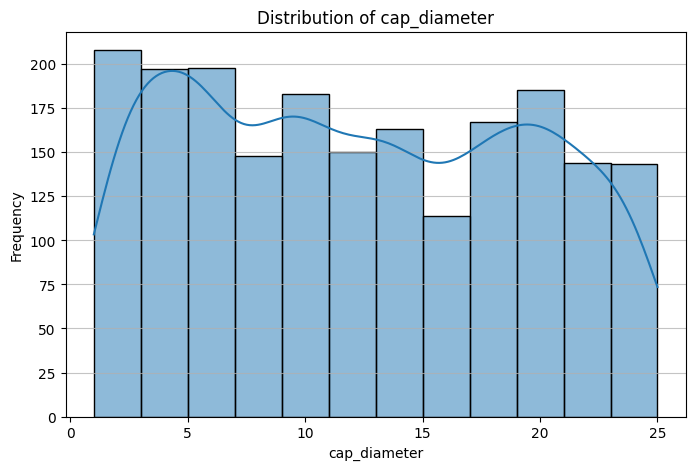

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude 'Unnamed: 0' if it's treated as an identifier and not a numerical feature for distribution analysis
if 'Unnamed: 0' in numerical_cols:
    numerical_cols.remove('Unnamed: 0')

print(f"Numerical columns identified: {numerical_cols}")

# Plot histograms for numerical features
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


**Reasoning**:
To analyze the distribution of categorical features, I will identify them and then display the value counts for each, excluding the 'Unnamed: 0' column as it's an identifier.



In [3]:
import pandas as pd

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'Unnamed: 0' if it's in the list
if 'Unnamed: 0' in categorical_cols:
    categorical_cols.remove('Unnamed: 0')

print(f"Categorical columns identified: {categorical_cols}\n")

# Print value counts for categorical features
for col in categorical_cols:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n")

Categorical columns identified: ['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape', 'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat', 'class']

Value counts for 'cap_shape':
cap_shape
sunken     439
flat       402
bell       397
convex     381
conical    381
Name: count, dtype: int64


Value counts for 'cap_surface':
cap_surface
scaly      568
smooth     513
fibrous    482
grooves    437
Name: count, dtype: int64


Value counts for 'cap_color':
cap_color
brown     263
green     241
yellow    228
gray      226
pink      221
buff      220
red       216
white     200
purple    185
Name: count, dtype: int64


Value counts for 'bruises':
bruises
yes    1023
no      977
Name: count, dtype: int64


Value counts for 'odor':
odor
foul      

Numerical Correlation Matrix:
              stalk_height  cap_diameter
stalk_height      1.000000     -0.003486
cap_diameter     -0.003486      1.000000


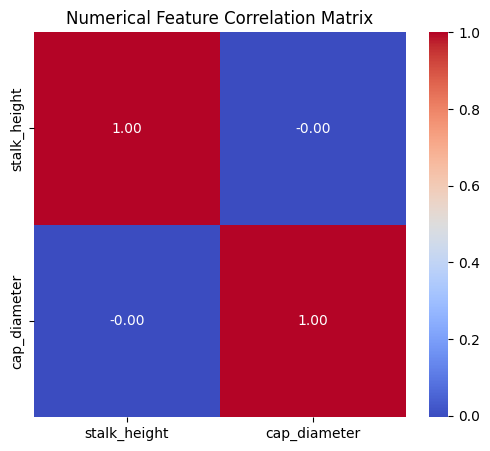

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select numerical columns for correlation analysis
numerical_df = df[numerical_cols]

# Calculate the correlation matrix
numerical_correlation_matrix = numerical_df.corr()

print("Numerical Correlation Matrix:")
print(numerical_correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(numerical_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.show()

**Reasoning**:
I will define a function to compute Cramer's V, which is a measure of association between two nominal variables. Then, I'll iterate through all pairs of categorical columns, calculate Cramer's V for each pair, and store the results in a DataFrame. Finally, I will visualize this categorical correlation matrix using a heatmap.




Cramer's V Matrix for Categorical Features:
                          cap_shape  cap_surface  cap_color  bruises  odor  \
cap_shape                      1.00         0.05       0.08     0.04  0.10   
cap_surface                    0.05         1.00       0.08     0.03  0.08   
cap_color                      0.08         0.08       1.00     0.05  0.09   
bruises                        0.04         0.03       0.05     1.00  0.07   
odor                           0.10         0.08       0.09     0.07  1.00   
gill_attachment                0.05         0.06       0.05     0.03  0.09   
gill_spacing                   0.07         0.04       0.08     0.02  0.06   
gill_size                      0.03         0.05       0.10     0.03  0.02   
gill_color                     0.11         0.12       0.12     0.13  0.10   
stalk_shape                    0.07         0.00       0.10     0.00  0.03   
stalk_root                     0.08         0.09       0.11     0.00  0.07   
stalk_surface_above

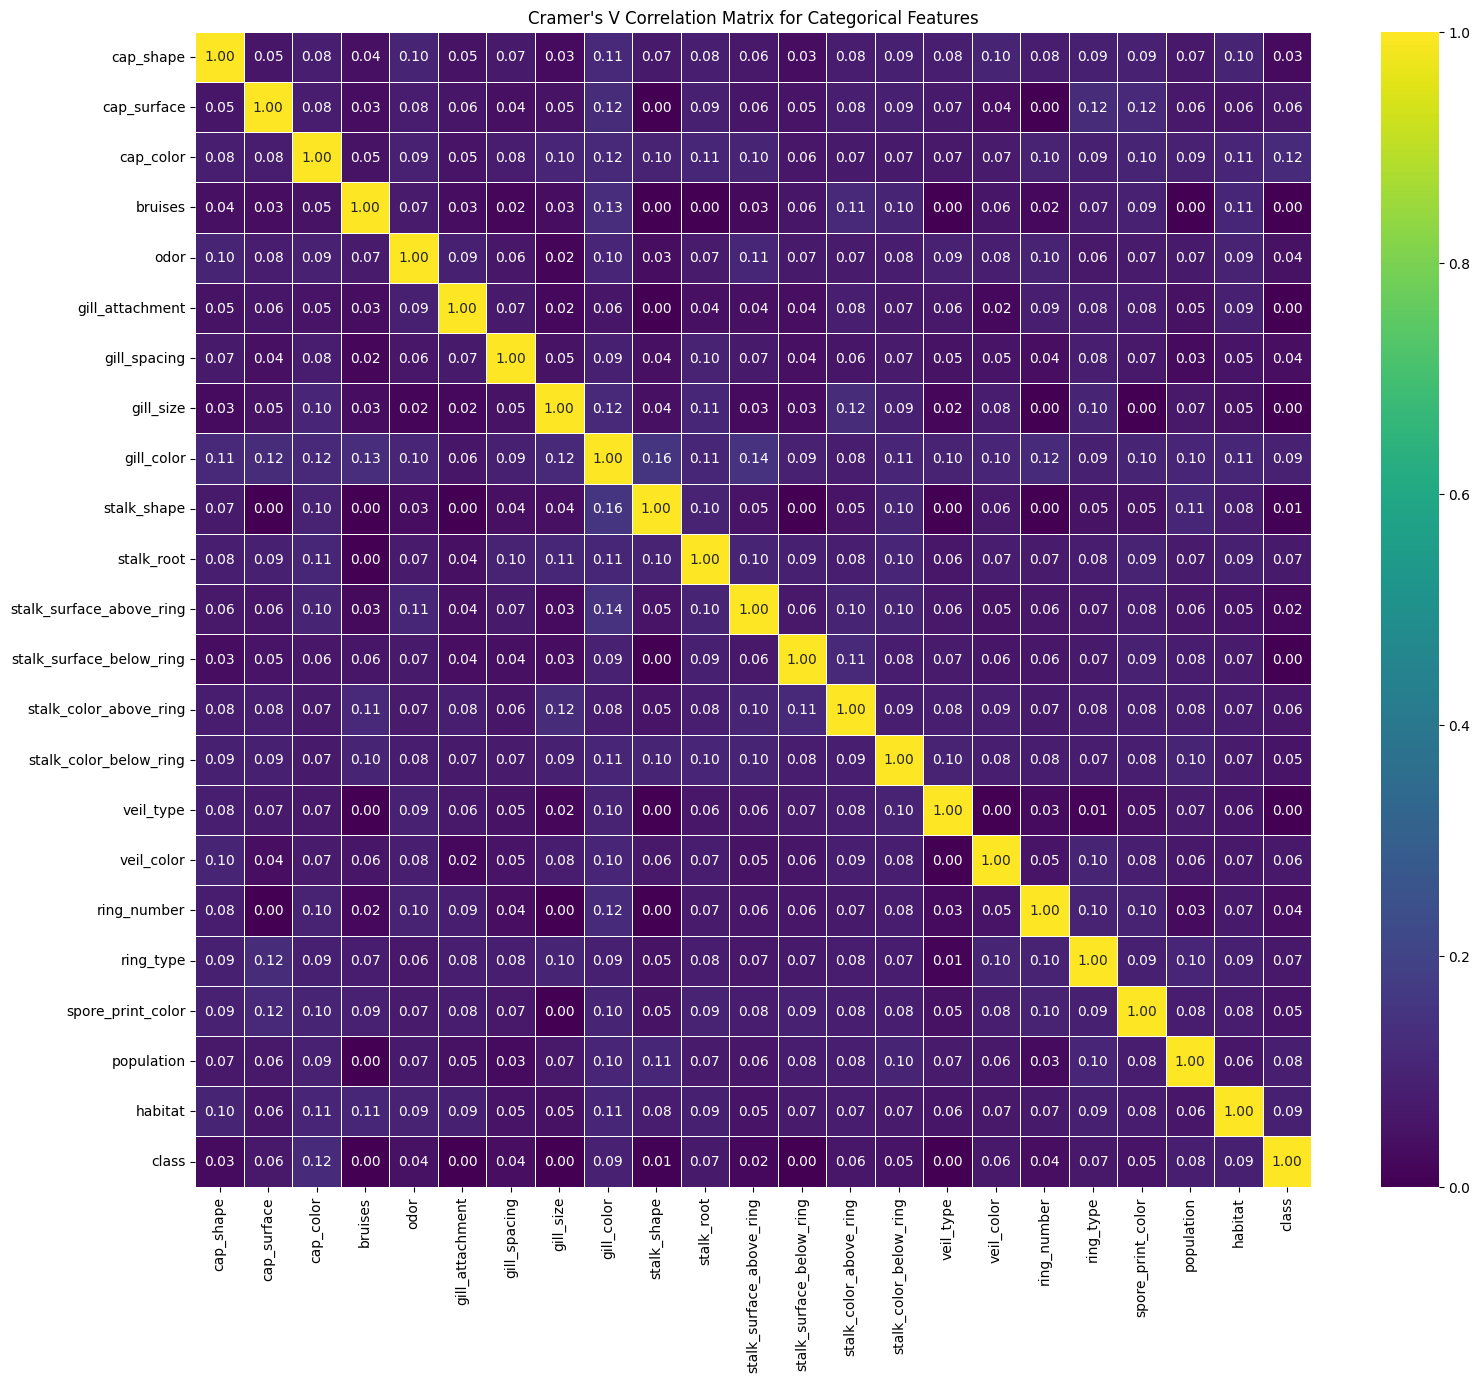

In [5]:
import numpy as np
from scipy.stats import chi2_contingency

# Function to calculate Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Get categorical columns (already defined in previous steps)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'Unnamed: 0' if it's in the list
if 'Unnamed: 0' in categorical_cols:
    categorical_cols.remove('Unnamed: 0')

# Initialize an empty DataFrame for Cramer's V matrix
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Calculate Cramer's V for all pairs of categorical columns
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0 # Correlation with itself is 1
        else:
            v_score = cramers_v(df[col1], df[col2])
            cramers_v_matrix.loc[col1, col2] = v_score

# Convert to float for heatmap visualization
cramers_v_matrix = cramers_v_matrix.astype(float)

print("\nCramer's V Matrix for Categorical Features:")
print(cramers_v_matrix.round(2))

# Plot the heatmap
plt.figure(figsize=(18, 15)) # Adjust figure size for better readability
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Cramer's V Correlation Matrix for Categorical Features")
plt.show()

## Encode Categorical Variables

### Subtask:
Encode categorical variables into a numerical format suitable for machine learning models, if necessary.


**Reasoning**:
To encode categorical variables, I will first separate the numerical and categorical columns. Then, I will apply one-hot encoding to the identified categorical feature columns (excluding 'Unnamed: 0') using `pd.get_dummies` and label encode the 'class' target variable. Finally, I will concatenate these encoded features with the original numerical features into a new DataFrame `df_encoded`.



In [6]:
import pandas as pd

# Identify numerical columns (excluding 'Unnamed: 0')
numerical_cols_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Unnamed: 0'], errors='ignore')

# Identify categorical columns (excluding 'Unnamed: 0' and 'class')
categorical_feature_cols = [col for col in df.select_dtypes(include='object').columns if col not in ['Unnamed: 0', 'class']]

# Apply one-hot encoding to categorical feature columns
df_encoded_features = pd.get_dummies(df[categorical_feature_cols], drop_first=False)

# Encode the 'class' target variable: 'edible' as 0, 'poisonous' as 1
df_class_encoded = df['class'].map({'edible': 0, 'poisonous': 1})

# Combine all numerical and encoded categorical features, and the encoded target variable
df_encoded = pd.concat([numerical_cols_df, df_encoded_features, df_class_encoded], axis=1)

# Display the first few rows of the encoded DataFrame
print("\nFirst 5 rows of the encoded DataFrame (df_encoded):")
print(df_encoded.head())

# Print a concise summary of the encoded DataFrame
print("\nEncoded DataFrame Info:")
df_encoded.info()


First 5 rows of the encoded DataFrame (df_encoded):
   stalk_height  cap_diameter  cap_shape_bell  cap_shape_conical  \
0     14.276173      5.054983           False              False   
1      3.952715     19.068319           False              False   
2      9.054265      7.205884           False              False   
3      5.226499     20.932692            True              False   
4     14.037532     12.545245           False              False   

   cap_shape_convex  cap_shape_flat  cap_shape_sunken  cap_surface_fibrous  \
0             False           False              True                False   
1             False           False              True                 True   
2             False            True             False                False   
3             False           False             False                False   
4             False            True             False                False   

   cap_surface_grooves  cap_surface_scaly  ...  population_several  \

## Split Dataset

### Subtask:
Split the preprocessed dataset into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare the data for model training, I will separate the features (X) and the target variable (y) from the `df_encoded` DataFrame, and then split them into training and testing sets using `train_test_split`.



In [7]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1400, 126)
Shape of X_test: (600, 126)
Shape of y_train: (1400,)
Shape of y_test: (600,)


## Visualize Feature Relationships

### Subtask:
Employ scatter plots, pair plots, or other relevant visualizations to comprehend relationships between different features.


**Reasoning**:
To visualize the relationship between 'stalk_height' and 'cap_diameter', I will create a scatter plot using `seaborn.scatterplot`, labeling the axes appropriately and adding a descriptive title.



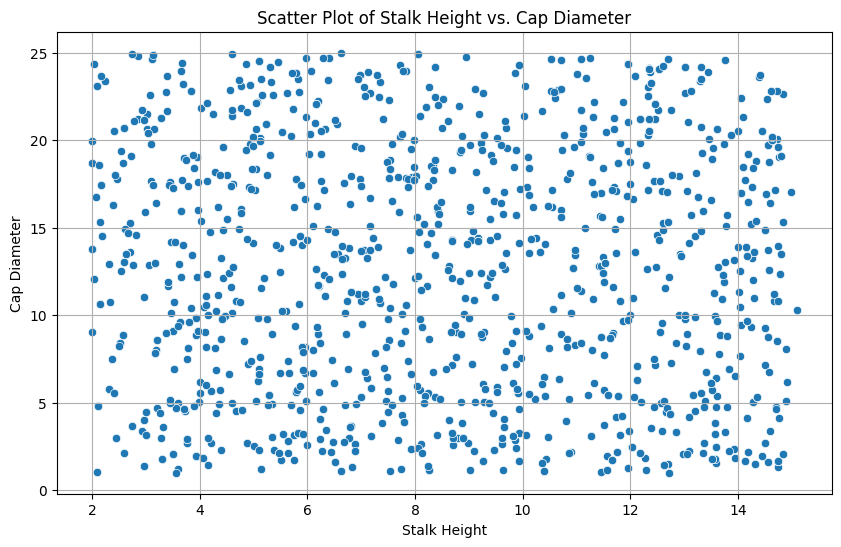

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of stalk_height vs. cap_diameter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='stalk_height', y='cap_diameter')
plt.xlabel('Stalk Height')
plt.ylabel('Cap Diameter')
plt.title('Scatter Plot of Stalk Height vs. Cap Diameter')
plt.grid(True)
plt.show()

**Reasoning**:
To further visualize the relationships between the numerical features, I will create a pair plot using `seaborn.pairplot` for 'stalk_height' and 'cap_diameter'. This will provide both scatter plots between the two features and histograms for each individual feature, offering a comprehensive view of their distributions and interactions.



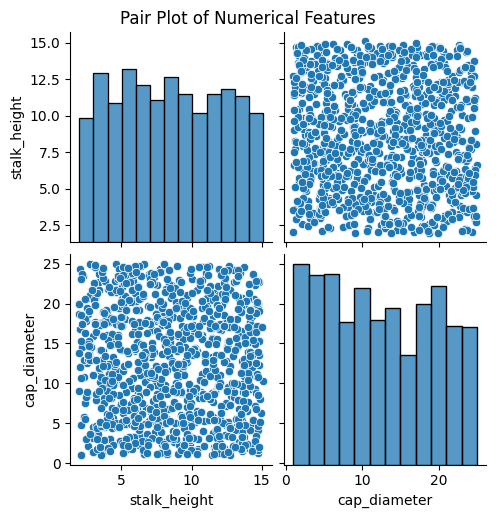

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pair plot for the numerical features
numerical_cols = ['stalk_height', 'cap_diameter']
sns.pairplot(df[numerical_cols])
plt.suptitle('Pair Plot of Numerical Features', y=1.02) # Adjust suptitle position
plt.show()

## Visualize Class Distributions

### Subtask:
Visualize the distribution of the target class to assess dataset balance or imbalance.


**Reasoning**:
To visualize the distribution of the target class, I will use `seaborn.countplot` on the `y` Series, which represents the 'class' variable. This will show the count of 'edible' and 'poisonous' mushrooms, allowing me to assess the dataset's balance.



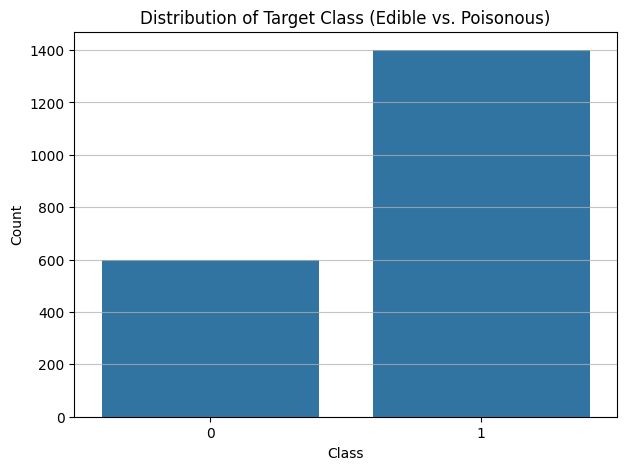

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target class
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title('Distribution of Target Class (Edible vs. Poisonous)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Implement SVM Classifier

### Subtask:
Implement a basic Support Vector Machine (SVM) classifier using Python libraries like scikit-learn.


**Reasoning**:
To implement a basic SVM classifier, I will import the SVC class and instantiate it with default parameters, storing it in `svm_model`.



In [11]:
from sklearn.svm import SVC

# Instantiate an SVC classifier with default parameters
svm_model = SVC()

print("SVM classifier instantiated successfully.")

SVM classifier instantiated successfully.


**Reasoning**:
With the SVM classifier instantiated, the next step is to train it using the prepared training data (`X_train` and `y_train`).



In [12]:
from sklearn.svm import SVC

# Instantiate an SVC classifier with default parameters
svm_model = SVC()

print("SVM classifier instantiated successfully.")

SVM classifier instantiated successfully.


**Reasoning**:
With the SVM classifier instantiated, the next step is to train it using the prepared training data (`X_train` and `y_train`).



In [13]:
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


## Evaluate SVM Performance

### Subtask:
Evaluate the trained SVM model's performance on the testing data using appropriate metrics such as accuracy, precision, recall, and F1-score.


**Reasoning**:
To evaluate the trained SVM model, I will first make predictions on the test data. Then, I will import necessary metrics from `sklearn.metrics` and calculate accuracy, precision, recall, and F1-score, along with the confusion matrix, printing all the results.



In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Compute and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.6917
Precision: 0.6917
Recall: 1.0000
F1-Score: 0.8177

Confusion Matrix:
[[  0 185]
 [  0 415]]


## Visualize SVM Results

### Subtask:
Visualize the classification results of the SVM model on the testing data to understand its predictions.


**Reasoning**:
To visualize the classification results, I will use `ConfusionMatrixDisplay` to plot the confusion matrix and `classification_report` to display detailed metrics.



<Figure size 800x600 with 0 Axes>

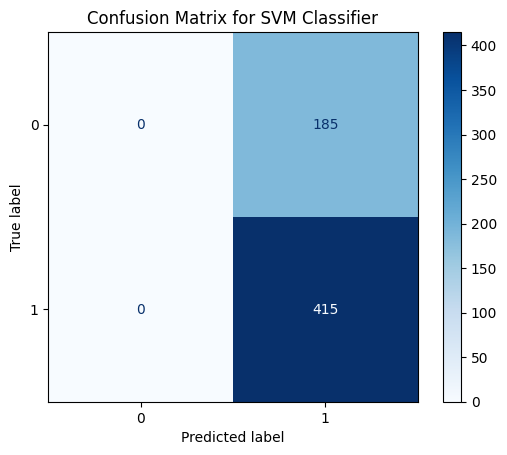


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       185
           1       0.69      1.00      0.82       415

    accuracy                           0.69       600
   macro avg       0.35      0.50      0.41       600
weighted avg       0.48      0.69      0.57       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Create a confusion matrix display
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


**Reasoning**:
The previous code block failed because it incorrectly tried to include markdown text within a Python cell, resulting in a `SyntaxError`. I will correct this by placing the descriptive text in a markdown cell and then providing the actual Python code for scaling numerical features using `StandardScaler` in a separate code cell. This involves identifying the numerical columns in `X_train` and `X_test` and applying `StandardScaler` to them, fitting it on the training data and transforming both training and testing sets.



In [23]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols_to_scale = ['stalk_height', 'cap_diameter']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing sets
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in X_train and X_test scaled successfully.")
print("First 5 rows of scaled X_train numerical features:")
print(X_train[numerical_cols_to_scale].head())
print("\nFirst 5 rows of scaled X_test numerical features:")
print(X_test[numerical_cols_to_scale].head())

Numerical features in X_train and X_test scaled successfully.
First 5 rows of scaled X_train numerical features:
      stalk_height  cap_diameter
836      -1.766659      0.625481
575      -0.556673     -0.862697
557      -0.559778     -1.335666
1235      1.580497      0.181843
1360     -0.943633     -0.849738

First 5 rows of scaled X_test numerical features:
      stalk_height  cap_diameter
1860     -0.943616     -0.345790
353       1.381258     -1.184221
1333      1.410808     -0.477295
905      -0.567014     -0.677114
1289      0.493712      0.185274


**Reasoning**:
Now that the numerical features have been successfully scaled, I will re-instantiate and retrain the SVM classifier with the scaled training data. This will allow the model to leverage the scaled features and potentially improve its performance.



In [24]:
from sklearn.svm import SVC

# Re-instantiate an SVC classifier with default parameters
svm_model = SVC()

# Train the SVM model with the scaled training data
svm_model.fit(X_train, y_train)

print("SVM classifier re-instantiated and retrained successfully with scaled data.")

SVM classifier re-instantiated and retrained successfully with scaled data.


# Task
The previous code cell `a109b820` was incorrectly formatted as a Python cell containing markdown text, leading to a `SyntaxError`. I will correct this by changing the `cell_type` of `a109b820` to `text_cell` to properly display the descriptive text.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the scaled test set with the retrained model
y_pred_scaled = svm_model.predict(X_test)

# Calculate evaluation metrics for the retrained model
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled)
recall_scaled = recall_score(y_test, y_pred_scaled)
f1_scaled = f1_score(y_test, y_pred_scaled)

# Print the metrics
print(f"Accuracy after scaling: {accuracy_scaled:.4f}")
print(f"Precision after scaling: {precision_scaled:.4f}")
print(f"Recall after scaling: {recall_scaled:.4f}")
print(f"F1-Score after scaling: {f1_scaled:.4f}")

# Compute and print the confusion matrix
conf_matrix_scaled = confusion_matrix(y_test, y_pred_scaled)
print("\nConfusion Matrix after scaling:")
print(conf_matrix_scaled)

Accuracy after scaling: 0.8100
Precision after scaling: 0.7900
Recall after scaling: 0.9880
F1-Score after scaling: 0.8779

Confusion Matrix after scaling:
[[ 76 109]
 [  5 410]]


## Change cell type to text_cell

### Subtask:
Change the `cell_type` of cell `a109b820` from `code_cell` to `text_cell` to properly display the descriptive text.


### Note on Cell Type Change:

The subtask requires changing the `cell_type` of cell `a109b820` from `code_cell` to `text_cell`. This is a metadata modification of the notebook cell itself, which is outside the scope of direct code generation within a `code_block` by this agent. You will need to manually perform this action using the notebook interface or an external `edit_cell` command if your environment supports it.

Once you have manually changed the cell type of `a109b820`, you can consider this subtask completed.

## Visualize SVM Results (After Scaling)

### Subtask:
Visualize the classification results of the retrained SVM model on the testing data after scaling to understand its improved predictions.


**Reasoning**:
To visualize the classification results of the retrained SVM model after scaling, I will create a confusion matrix display using `ConfusionMatrixDisplay.from_predictions` and then generate a detailed classification report.



<Figure size 800x600 with 0 Axes>

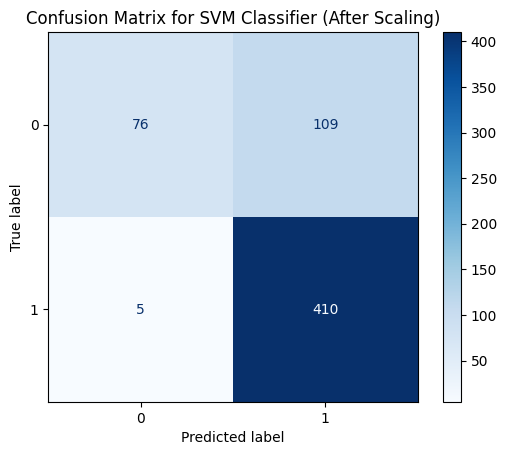


Classification Report (After Scaling):
              precision    recall  f1-score   support

           0       0.94      0.41      0.57       185
           1       0.79      0.99      0.88       415

    accuracy                           0.81       600
   macro avg       0.86      0.70      0.72       600
weighted avg       0.84      0.81      0.78       600



In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Create a confusion matrix display after scaling
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled, cmap='Blues')
plt.title('Confusion Matrix for SVM Classifier (After Scaling)')
plt.show()

# Generate and print the classification report after scaling
print("\nClassification Report (After Scaling):")
print(classification_report(y_test, y_pred_scaled))